In [1]:
import sys, subprocess, glob, os, shutil, re, importlib, Bio, datetime
from subprocess import call
from Bio import SeqIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import rpy2
import seaborn as sns
# %load_ext rpy2.ipython
import matplotlib.colors as mcolors
from matplotlib.patches import Patch



from collections import defaultdict
%matplotlib inline
import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.lines as mlines
from matplotlib.font_manager import FontProperties
import matplotlib.colors as clr
import textwrap as textwrap
from textwrap import wrap

import numpy as np
from scipy.special import binom
import baltic as bt

In [2]:
# ##my mcc.trees don't have the yyyy-mm-dd in the strain "metadata" which seems to be messing things up
# ##so these functions are to add a yyyy-mm-dd item into the strain info for every mcc in a directory
# ##define the input directory and a new output directory for the dates_worked versions
# import os
# import re
# from datetime import datetime, timedelta

# def decimal_to_date(decimal):
#     year = int(decimal)
#     start = datetime(year, 1, 1)
#     next_year = datetime(year + 1, 1, 1)
#     days_in_year = (next_year - start).days
#     day_offset = (decimal - year) * days_in_year
#     return (start + timedelta(days=day_offset)).strftime('%Y-%m-%d')

# def process_line(line):
#     if line.count('|') != 5:
#         return line

#     match = re.search(r"'([^']+)'", line)
#     if not match:
#         return line

#     label = match.group(1)
#     parts = label.split('|')

#     try:
#         decimal_date = float(parts[1])
#         iso_date = decimal_to_date(decimal_date)

#         if len(parts) > 2 and re.match(r'^\d{4}-\d{2}-\d{2}$', parts[2]):
#             return line  # Already processed

#         parts.insert(2, iso_date)
#         new_label = '|'.join(parts)
#         return line.replace(label, new_label)
#     except Exception:
#         return line

# def process_directory(input_dir, output_dir):
#     os.makedirs(output_dir, exist_ok=True)

#     for filename in os.listdir(input_dir):
#         if filename.endswith('.trees') or filename.endswith('.tree'):
#             input_path = os.path.join(input_dir, filename)
#             output_path = os.path.join(output_dir, filename)

#             with open(input_path, 'r') as infile:
#                 lines = infile.readlines()

#             with open(output_path, 'w') as outfile:
#                 for line in lines:
#                     outfile.write(process_line(line))

In [24]:
# # input_directory = '../joint_est/2025_04_14_allWI_dt_popprop_50plus/results/2025_04_15_wi_dt_poprop_urbrur_jointest/log_combined/mcc_trees/'
# # output_directory = '../joint_est/2025_04_14_allWI_dt_popprop_50plus/results/2025_04_15_wi_dt_poprop_urbrur_jointest/log_combined/mcc_trees/dates_fixed/'
# input_directory = '../joint_est/mn/2025-08-15-om-mn-adi-50plus/results/2025-08-20-mn-om-adi-jointest-v2/log_combined/mcc_trees/'
# output_directory = '../joint_est/mn/2025-08-15-om-mn-adi-50plus/results/2025-08-20-mn-om-adi-jointest-v2/log_combined/mcc_trees/dates_fixed/'

# process_directory(input_directory, output_directory)

In [15]:
pwd

'/Users/asjaeger/Desktop/project_source/midwest_sars2/beast/beast_post_processing'

In [2]:

# # # Define colors for the node probabilities
# # Rural_color = '#fcd64e'
# # Urban_color = '#478778'
# # node_colors2 = clr.LinearSegmentedColormap.from_list('custom', [Urban_color, Rural_color], N=256)

def return_metadata_dictionaries(tree):
    metadata = {}
    node_types = {}
    node_probs = {}

    # for k in tree.Objects:
    #     if isinstance(k, bt.leaf) or k.branchType == 'leaf':
    #         adi_status = k.traits.get('location', None)
    #         urbrur_status = k.name.split("|")[3] if "|" in k.name else None
    #         metadata[k] = {"urbrur_status": urbrur_status, "adi_status": adi_status}

    #     if isinstance(k, bt.node) or k.branchType == 'node':
    #         node_adi_status = k.traits.get("location", None)
    #         node_types[k] = {"node_adi_status": node_adi_status}

    #         # handle probabilities for multi-category location
    #         node_probs[k] = {}

    #         if "location.set" in k.traits and "location.set.prob" in k.traits:
    #             locations = list(k.traits["location.set"])
    #             probs = list(k.traits["location.set.prob"])

    #             for loc, prob in zip(locations, probs):
    #                 node_probs[k][loc] = prob

    #         else:
    #             # single-state location
    #             node_probs[k][node_adi_status] = 1.0
    for k in tree.Objects:
        if isinstance(k, bt.leaf) or k.branchType == 'leaf':
            pany_dom_status = k.traits.get('pa_ny_dom', None)
            state_status = k.name.split("|")[4] if "|" in k.name else None
            metadata[k] = {"state_status": state_status, "pany_dom_status": pany_dom_status}

        if isinstance(k, bt.node) or k.branchType == 'node':
            node_pany_dom_status = k.traits.get("pa_ny_dom", None)
            node_types[k] = {"node_pany_dom_status": node_pany_dom_status}

            # handle probabilities for multi-category location
            node_probs[k] = {}

            if "pa_ny_dom.set" in k.traits and "pa_ny_dom.set.prob" in k.traits:
                locations = list(k.traits["pa_ny_dom.set"])
                probs = list(k.traits["pa_ny_dom.set.prob"])

                for loc, prob in zip(locations, probs):
                    node_probs[k][loc] = prob

            else:
                # single-state location
                node_probs[k][node_pany_dom_status] = 1.0

    return metadata, node_types, node_probs

def process_trees_in_directory(directory):
    metadata_dict = {}
    all_node_probs = defaultdict(list)  # Store node probabilities for all trees
    all_metadata = defaultdict(list)  # Store metadata for all trees
    tree_files = [f for f in os.listdir(directory) if f.endswith('.mcc.tree')]

    for tree_file in tree_files:
        tree_path = os.path.join(directory, tree_file)
        tree = bt.loadNexus(tree_path)
        
        # Unpack all three values from return_metadata_dictionaries
        metadata, node_types, node_probs = return_metadata_dictionaries(tree)
        
        # Store metadata and probabilities in the dictionaries
        metadata_dict[tree_file] = {"tree": tree, "metadata": metadata, "node_probs": node_probs}
        
        # Collect node probabilities for later use in a dataframe
        all_metadata[tree_file].append(metadata)
        for k, prob in node_probs.items():
            all_node_probs[tree_file].append(prob)

    return metadata_dict, all_metadata, all_node_probs

# Function to create a DataFrame from node probabilities
def create_node_probs_df(all_node_probs):
    # Flatten the dictionary into a list of rows for the DataFrame
    rows = []
    for tree, node_probs_list in all_node_probs.items():
        for i, prob in enumerate(node_probs_list):
            rows.append({'tree': tree, 'node': i, 'probability': prob})

    # Create DataFrame
    df = pd.DataFrame(rows)
    return df


In [3]:
lbm_tips ={"A/chicken/Pennsylvania/c_lbm1/2025|2025-02-20|lbm|PA_domestic|PA|galliformes|",
"A/chicken/Pennsylvania/c_lbm10/2025|2025-03-11|lbm|PA_domestic|PA|galliformes|",
"A/chicken/Pennsylvania/c_lbm2/2025|2025-02-20|lbm|PA_domestic|PA|galliformes|",
"A/chicken/Pennsylvania/c_lbm3/2025|2025-02-20|lbm|PA_domestic|PA|galliformes|",
"A/chicken/Pennsylvania/c_lbm4/2025|2025-02-20|lbm|PA_domestic|PA|galliformes|",
"A/chicken/Pennsylvania/c_lbm5/2025|2025-03-10|lbm|PA_domestic|PA|galliformes|",
"A/chicken/Pennsylvania/c_lbm6/2025|2025-03-10|lbm|PA_domestic|PA|galliformes|",
"A/chicken/Pennsylvania/c_lbm7/2025|2025-03-10|lbm|PA_domestic|PA|galliformes|",
"A/chicken/Pennsylvania/c_lbm8/2025|2025-03-10|lbm|PA_domestic|PA|galliformes|",
"A/chicken/Pennsylvania/c_lbm9/2025|2025-03-11|lbm|PA_domestic|PA|galliformes|",
"A/chukar/Pennsylvania/ckr_lbm1/2025|2025-02-20|lbm|PA_domestic|PA|galliformes|",
"A/duck/Pennsylvania/d_lbm1/2025|2025-02-20|lbm|PA_domestic|PA|anseriformes|",
"A/duck/Pennsylvania/d_lbm2/2025|2025-02-20|lbm|PA_domestic|PA|anseriformes|",
"A/duck/Pennsylvania/d_lbm3/2025|2025-03-10|lbm|PA_domestic|PA|anseriformes|",
"A/duck/Pennsylvania/d_lbm4/2025|2025-03-11|lbm|PA_domestic|PA|anseriformes|",
"A/goose/Pennsylvania/g_lbm1/2025|2025-02-20|lbm|PA_domestic|PA|anseriformes|",
"A/guinea/Pennsylvania/gn_lbm1/2025|2025-02-20|lbm|PA_domestic|PA|galliformes|"}

In [4]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.lines import Line2D

plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex='false') 

# Define colors for the location categories
padom_color = '#fcd64e'
nydom_color = '#478778'
dom_color = '#f3722c'
wild_color = '#4d9de0'

panydom_color_map = {
    "PA_domestic": padom_color,
    "NY_domestic": nydom_color,
    "domestic": dom_color,
    "wild": wild_color
}

def plot_all_trees_stacked(metadata_dict, width=12, height=30):
    # Set up the figure
    fig, ax = plt.subplots(figsize=(width, height), facecolor='w')

    # Set some parameters for plotting
    branchWidth = 2.0
    tipSize = 45
    cumulative_y = 0.9  # This will be used to shift each tree vertically
    vertical_scaling_factor = 5  # Increase this factor to give each tree more vertical space

    # Loop over each tree and plot
    for tree_file, data in metadata_dict.items():
        tree = data['tree']
        metadata = data['metadata']
        node_probs = data['node_probs']

        # Plot each node and tip
        for k in tree.Objects:
            x = k.absoluteTime
            y = k.y + cumulative_y
            xp = k.parent.absoluteTime if k.parent else x

            # Get location and probability
            location = k.traits.get("pa_ny_dom", "pa_ny_dom")
            prob = k.traits.get("pa_ny_dom.prob", 0.5)  # Default prob to 0.5 if not available

            # Get the color for the specific location
            base_color = panydom_color_map.get(location, "#808080")
            
            # Set alpha transparency based on prob value; keep a small default alpha if prob is 0
            alpha = prob if prob > 0 else 0.2  # For nodes with prob 0, set a minimal alpha
            rgba = mcolors.to_rgba(base_color, alpha=alpha)

            # Plot vertical lines (for nodes only, not leaves)
            if hasattr(k, 'children') and k.children:
                ymin = min(child.y for child in k.children) + cumulative_y
                ymax = max(child.y for child in k.children) + cumulative_y
                ax.plot([x, x], [ymin, ymax], lw=branchWidth, color=rgba, ls='-', zorder=8)

            # Plot horizontal branch
            ax.plot([xp, x], [y, y], lw=branchWidth, color=rgba, ls='-', zorder=8)

            # Plot tip if leaf
            if k.branchType == 'leaf':
                tip_color = panydom_color_map.get(metadata[k]["pany_dom_status"], "#808080")
                ax.scatter(x, y, s=tipSize, facecolor=tip_color, edgecolor='black', zorder=11)

                if k.name in lbm_tips:
                    # Different shape (star) for highlighted tips
                    ax.scatter(x, y, s=tipSize * 3, facecolor=tip_color,
                               edgecolor='black', marker='*', zorder=12)
                else:
                    ax.scatter(x, y, s=tipSize, facecolor=tip_color,
                               edgecolor='black', marker='o', zorder=11)
                
                # Add tip label from state_status metadata
                state_label = metadata[k].get("state_status", "")
                if state_label != "other": ##i don't want to label where it is other, i just want to highlight NJ
                    ax.text(x + 0.008, y, state_label,
                        fontsize=10, va='center', ha='left', zorder=12)

        # # Add tree label -will have to adjust placement by wave
        # label_y = cumulative_y + tree.ySpan / 2
        # ax.text(2021.5, label_y, tree_file.replace('_alignment_w_meta.mcc.tree', ''), 
        #         ha='right', va='center', fontsize=18)

        cumulative_y += tree.ySpan - .1

    # Clean up plot
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylim(-1, cumulative_y)
#alpha:
    # ax.set_xlim(2020, 2022)
    # ax.tick_params(axis='y', labelsize=0, size=0)
    # ax.tick_params(axis='x', labelsize=14, size=5, width=2, color='grey')
    # ax.set_xticks([2020, 2020.5, 2021, 2021.5, 2022])
    # ax.set_xticklabels(['2020', '2020.5', '2021', '2021.5', '2022'])
#delta
    # ax.set_xlim(2020, 2022.5)
    # ax.tick_params(axis='y', labelsize=0, size=0)
    # ax.tick_params(axis='x', labelsize=14, size=5, width=2, color='grey')
    # ax.set_xticks([2020.5, 2021, 2021.5, 2022, 2022.5])
    # ax.set_xticklabels(['2020.5', '2021', '2021.5', '2022', '2022.5'])

    ##tweaked for omicron
    ax.set_xlim(2024.75, 2025.4)
    ax.tick_params(axis='y', labelsize=0, size=0)
    ax.tick_params(axis='x', labelsize=14, size=5, width=2, color='grey')
    ax.set_xticks([2024.75, 2025, 2025.25])
    ax.set_xticklabels(['2024.75', '2025', '2025.25',])
    ax.set_yticklabels([])
    # ax.set_title("MN omicron wave, all sequences grouped adi DTA tree joint estimation", size=18)

    # # Add a color bar based on the new color map for location
    # ax_cb = fig.add_axes([0.92, 0.30, 0.02, 0.25])  # [left, bottom, width, height]
    # ticks = [0.0, 0.33, 0.67, 1.0]
    # mpl.colorbar.ColorbarBase(ax_cb, cmap=node_colors2, ticks=ticks)
    # ax_cb.set_yticklabels(['High_ADI', 'Mid_ADI', 'Low_ADI', 'Grouped_ADI'])
    # ax_cb.tick_params(size=2, labelsize=14)
# Create legend handles
    legend_elements = [
        Patch(facecolor=padom_color, edgecolor='black', label='pa_dom'),
        Patch(facecolor=nydom_color, edgecolor='black', label='ny_dom'),
        Patch(facecolor=dom_color, edgecolor='black', label='domestic'),
        Patch(facecolor=wild_color, edgecolor='black', label='wild'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
           markeredgecolor='black', markersize=14, label='LBM')
    ]
    
    # Add the legend to the plot
    ax.legend(
        handles=legend_elements,
        title='PA NY dom status',
        loc='upper left',
        bbox_to_anchor=(.75, 1),  # (x, y) — shift right and align to top
        borderaxespad=0.,
        fontsize=13,
        title_fontsize=14
    )
    # Save the figure
    # plt.savefig(combined_figure_filename, bbox_inches='tight', pad_inches=0)


In [3]:
pwd

'/Users/asjaeger/Desktop/project_source/hpai-PA/beast_d11_dta'

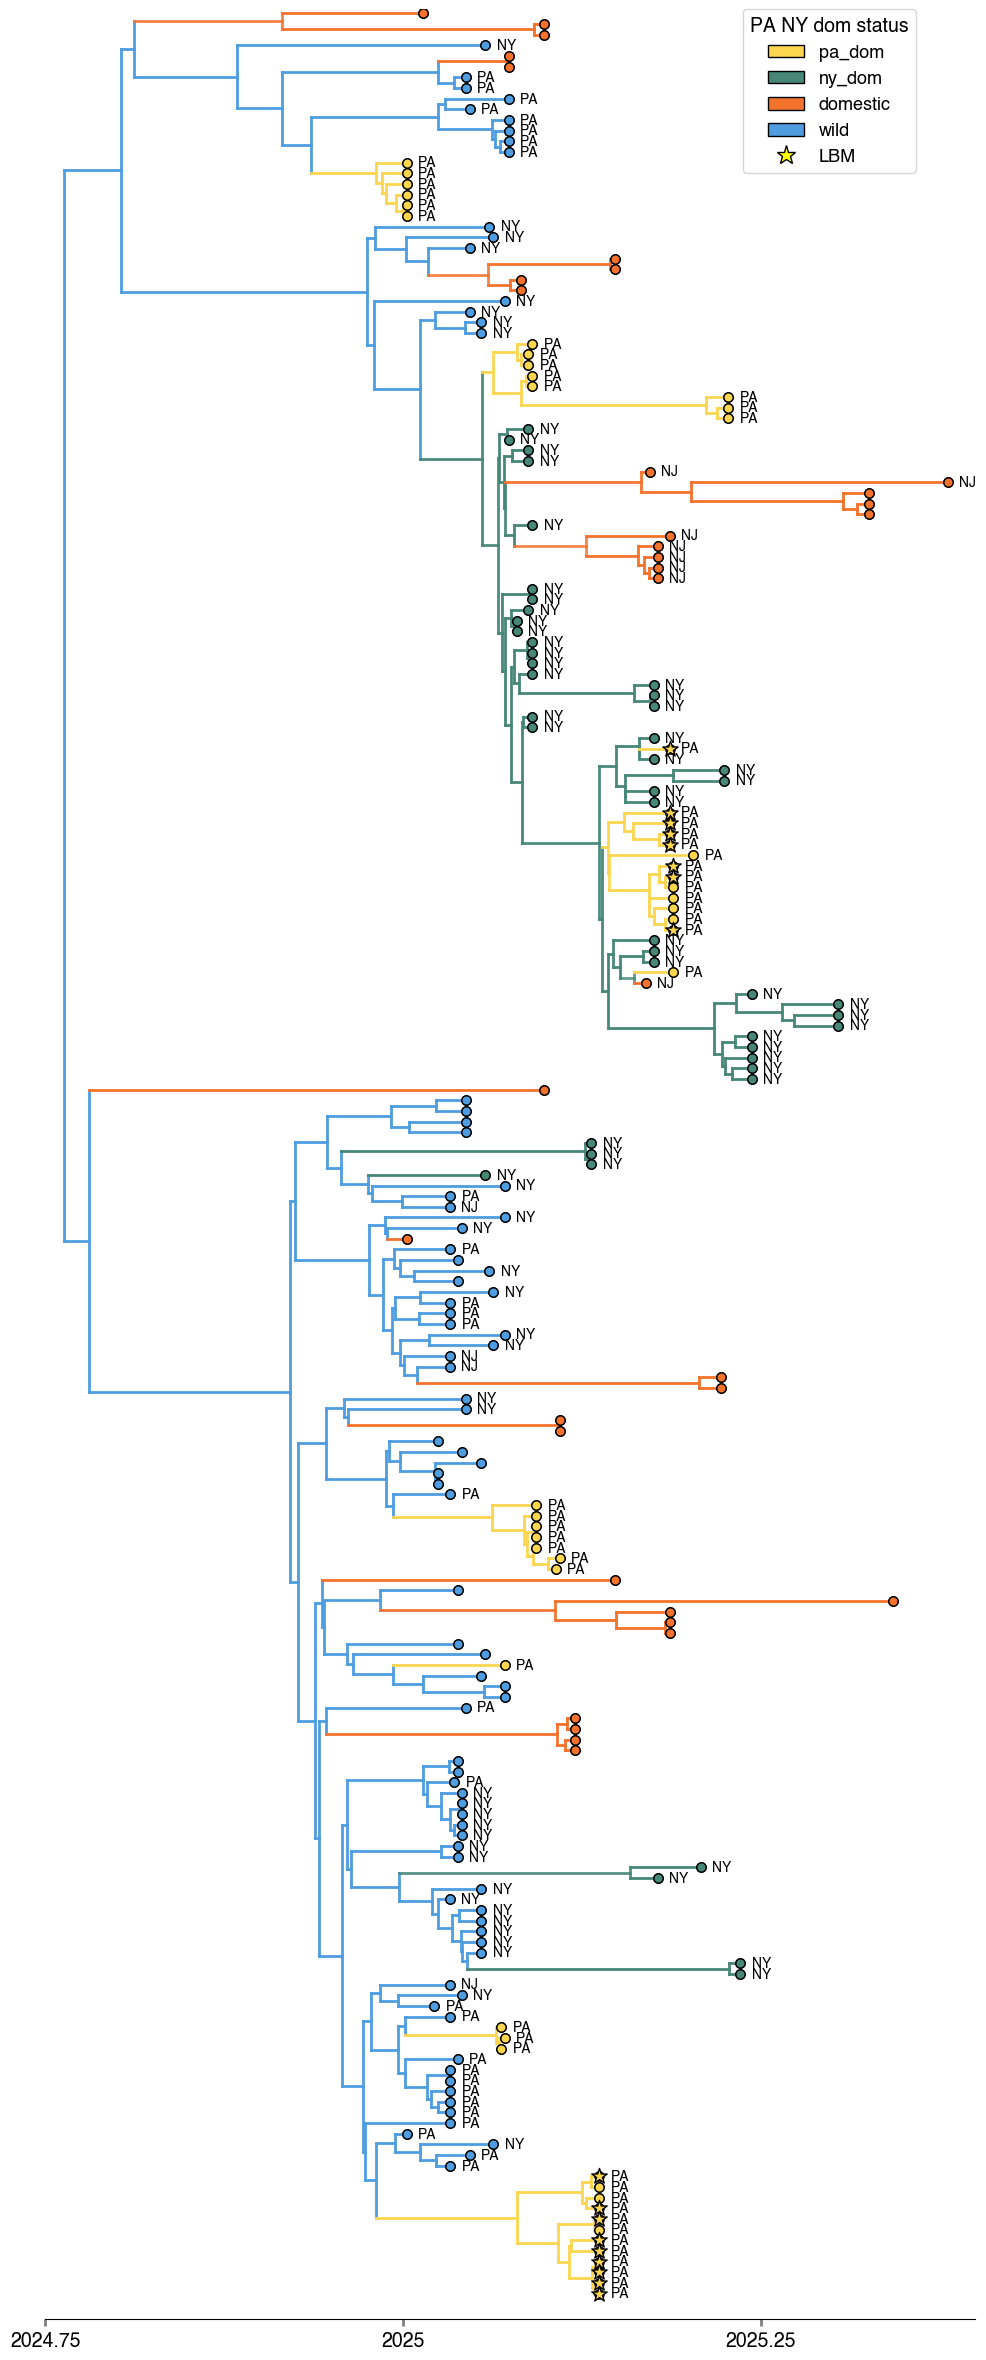

In [6]:
# # Example usage:
# directory = '../joint_est/2025_04_28_dt_wi_allseqs_adi_50plus/results/2025_04_29_allwi_dt_adi_jointest_50plus/log_combined/mcc_trees/dates_fixed/'
# combined_figure_filename = '../beast_post_processing/2025-05-01_dtWI_jointest_adi_mcctrees.pdf'
directory = '../results/2026-04-29-d11-dta-jmps-rwrds-215seq/good_its/log_combined/mcc_trees'
combined_figure_filename = 'testoutput_mcc.pdf'
metadata_dict, all_metadata, all_node_probs = process_trees_in_directory(directory)

# Create a DataFrame from the node probabilities
node_probs_df = create_node_probs_df(all_node_probs)

# Plot the stacked trees with the processed metadata
plot_all_trees_stacked(metadata_dict)

In [9]:
com_lbm_ny_pa_nj = pd.read_csv('../../output_dfs/com_lbm_pa_nj_case_cts.tsv', sep='\t')
com_lbm_ny_pa_nj.tail(30)

,Unnamed: 0,Special ID,County Name,State,Production,Confirmed Diagnosis,Control Area Released,Unnamed: 6,state_grouped,group
34,89,Westchester 01,Westchester,New York,WOAH Non-Poultry,2025-02-26,NaN,100,New York,New York - Other Commercial
35,97,Philadelphia 01,Philadelphia,Pennsylvania,Live Bird Market,2025-02-24,NaN,"1,100",Pennsylvania,Pennsylvania - LBM
36,98,Union 02,Union,New Jersey,Live Bird Market,2025-02-22,NaN,830,Other,New Jersey - LBM
37,101,Delaware 01,Delaware,New York,WOAH Non-Poultry,2025-02-21,NaN,240,New York,New York - Other Commercial
38,107,Butler 01,Butler,Pennsylvania,WOAH Non-Poultry,2025-02-20,NaN,610,Pennsylvania,Pennsylvania - Other Commercial
39,109,Luzerne 01,Luzerne,Pennsylvania,WOAH Non-Poultry,2025-02-20,NaN,90,Pennsylvania,Pennsylvania - Other Commercial
40,129,Lancaster 37,Lancaster,Pennsylvania,WOAH Poultry,2025-02-12,06-Mar-25,600,Pennsylvania,Pennsylvania - Other Commercial
41,137,Cumberland 02,Cumberland,Pennsylvania,Commercial Duck Meat Bird,2025-02-11,01-Mar-25,"20,000",Pennsylvania,Pennsylvania - Other Commercial
42,139,Lancaster 36,Lancaster,Pennsylvania,Commercial Broiler Production,2025-02-11,06-Mar-25,"80,000",Pennsylvania,Pennsylvania - Other Commercial
43,140,Madison 01,Madison,New York,WOAH Non-Poultry,2025-02-11,NaN,20,New York,New York - Other Commercial


In [10]:
com_lbm_ny_pa_nj['Confirmed Diagnosis'].min()

'2025-01-17'

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from datetime import datetime

##adapted from original code with help from Claude, sonnet 4.6
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})


# ── helper: calendar date → decimal year ──────────────────────────────────────
def date_to_decimal_year(dt):
    """Convert a datetime/Timestamp to a decimal year float."""
    if hasattr(dt, 'to_pydatetime'):
        dt = dt.to_pydatetime()
    year = dt.year
    start = datetime(year, 1, 1)
    end   = datetime(year + 1, 1, 1)
    return year + (dt - start).total_seconds() / (end - start).total_seconds()

# ── helper: decimal year → tick label ─────────────────────────────────────────
def decimal_year_to_label(dy):
    """Return a 'Mon YYYY' string for a decimal-year float."""
    year  = int(dy)
    start = datetime(year, 1, 1)
    end   = datetime(year + 1, 1, 1)
    dt    = start + (end - start) * (dy - year)
    return dt.strftime('%b %Y')


def monthly_decimal_ticks(xlim):
    """Generate decimal-year tick positions and labels for every month in xlim."""
    ticks, labels = [], []
    start_year = int(xlim[0])
    for year in range(start_year, int(xlim[1]) + 2):
        for month in range(1, 13):
            dt = datetime(year, month, 1)
            dy = date_to_decimal_year(dt)
            if xlim[0] <= dy <= xlim[1]:
                ticks.append(dy)
                labels.append(dt.strftime('%b %Y'))
    return ticks, labels

# ── colour maps (unchanged from your originals) ───────────────────────────────
padom_color  = '#fcd64e' #yellow
nydom_color  = '#4d9de0' #blue
# dom_color    = '#DD3162' #magenta
dom_color    = 'gray' #magenta

wild_color   = '#478778' #teal

panydom_color_map = {
    "PA_domestic": padom_color,
    "NY_domestic": nydom_color,
    "domestic":    dom_color,
    "wild":        wild_color,
}

case_colors = {
    'New York - LBM':                 '#023047',
    'New York - Other Commercial':    '#8ecae6',
    'Pennsylvania - LBM':             '#fb8500',
    'Pennsylvania - Other Commercial':'#ffb703',
    'New Jersey - LBM':               '#800080',
    'New Jersey - Other Commercial':  '#DA70D6',
}

# # Colors: for line plots vs bar plots
# case_colors = {
#     'New York - LBM':               '#4d9de0',  # light blue
#     'New York - Other Commercial':  '#4d9de0',  # light blue
#     'Pennsylvania - LBM':           '#fcd64e',  # orange
#     'Pennsylvania - Other Commercial': '#fcd64e', # orange
#     'New Jersey - LBM':             '#DA70D6', #pink purple
#     'New Jersey - Other Commercial':  '#DA70D6' #pink purple
# } 


linestyles = {
    'New York - LBM':                  '-',
    'New York - Other Commercial':     '--',
    'Pennsylvania - LBM':              '-',
    'Pennsylvania - Other Commercial': '--',
    'New Jersey - LBM':                '-',
    'New Jersey - Other Commercial':   '--'
}

# ── main combined plot ─────────────────────────────────────────────────────────
def plot_tree_with_cases(
    metadata_dict,          # your tree dict
    com_lbm_ny_pa_nj,       # your case-count DataFrame
    lbm_tips,               # set of tip names to mark with stars
    combined_figure_filename,
    xlim=(2024.75, 2025.4),
    # xticks=(2024.75, 2025.0, 2025.25),
    tree_height_ratio=5,    # rows of grid given to tree vs 1 row for cases
    width=14,
    tree_height=30,
    cases_height=4,
    max_cases=20,
):
    # ── 1. build the case-count pivot in DECIMAL YEAR ─────────────────────────
    com_lbm_ny_pa_nj = com_lbm_ny_pa_nj.copy()
    com_lbm_ny_pa_nj['Confirmed Diagnosis'] = pd.to_datetime(com_lbm_ny_pa_nj['Confirmed Diagnosis']) 

    com_lbm_ny_pa_nj['group'] = (
        com_lbm_ny_pa_nj['State'] + ' - ' +
        com_lbm_ny_pa_nj['Production'].apply(
            lambda x: 'LBM' if x == 'Live Bird Market' else 'Other Commercial'
        )
    )

    weekly = (
        com_lbm_ny_pa_nj
        .groupby(['group', pd.Grouper(key='Confirmed Diagnosis', freq='W-MON')])
        .size()
        .reset_index(name='cases')
    )
    # weekly = ( #actually testing monthly
    #     com_lbm_ny_pa_nj
    #     .groupby(['group', pd.Grouper(key='Confirmed Diagnosis', freq='MS')])
    #     .size()
    #     .reset_index(name='cases')
    # )
    weekly_pivot = weekly.pivot_table(
        index='Confirmed Diagnosis', columns='group', values='cases', fill_value=0
    )

    col_order = [c for c in [
        'New York - LBM', 'New York - Other Commercial',
        'Pennsylvania - LBM', 'Pennsylvania - Other Commercial',
        'New Jersey - LBM', 'New Jersey - Other Commercial',
    ] if c in weekly_pivot.columns]
    weekly_pivot = weekly_pivot[col_order]
    # print(weekly_pivot.index[:10])
    # Convert week index → decimal year (use midpoint of each Mon–Sun week)
    week_decimal = np.array([
        date_to_decimal_year(d + pd.Timedelta(days=3))   # Wed midpoint
        for d in weekly_pivot.index
    ])
    bar_width = 7 / 365.25   # one week in decimal-year units
    # bar_width = 30 / 365.25   # one week in decimal-year units


    # ── 2. figure layout ──────────────────────────────────────────────────────
    total_height = tree_height + cases_height
    fig = plt.figure(figsize=(width, total_height), facecolor='w')

    gs = gridspec.GridSpec(
        2, 1,
        height_ratios=[tree_height, cases_height],
        hspace=0.005,        # tiny gap between panels
    )

    ax_tree  = fig.add_subplot(gs[0])
    ax_cases = fig.add_subplot(gs[1], sharex=ax_tree)

    # ── 3. draw the TREE (your existing logic, adapted for ax_tree) ───────────
    branchWidth = 2.0
    tipSize     = 75
    cumulative_y = 0.5

    for tree_file, data in metadata_dict.items():
        tree       = data['tree']
        metadata   = data['metadata']

        for k in tree.Objects:
            x  = k.absoluteTime
            y  = k.y + cumulative_y
            xp = k.parent.absoluteTime if k.parent else x

            location = k.traits.get("pa_ny_dom", "pa_ny_dom")
            prob     = k.traits.get("pa_ny_dom.prob", 0.5)

            base_color = panydom_color_map.get(location, "#808080")
            alpha      = prob if prob > 0 else 0.2
            rgba       = mcolors.to_rgba(base_color, alpha=alpha)

            if hasattr(k, 'children') and k.children:
                number_children = len(k.leaves)
                node_branchwidth = branchWidth+number_children*0.025
                ymin = min(child.y for child in k.children) + cumulative_y
                ymax = max(child.y for child in k.children) + cumulative_y
                ax_tree.plot([x, x], [ymin, ymax],
                             lw=node_branchwidth, color=rgba, ls='-', zorder=8)

            ax_tree.plot([xp, x], [y, y],
                         lw=node_branchwidth, color=rgba, ls='-', zorder=8)

            if k.branchType == 'leaf':
                tip_color = panydom_color_map.get(
                    metadata[k].get("pany_dom_status", ""), "#808080"
                )
                # Override color to pink if domestic and NJ
                if (metadata[k].get("pany_dom_status") == "domestic" and
                        metadata[k].get("state_status") == "NJ"):
                    tip_color = "#FF69B4"

                if k.name in lbm_tips:
                    ax_tree.scatter(x, y, s=tipSize * 3, facecolor=tip_color,
                                    edgecolor='black', marker='*', zorder=12)
                else:
                    ax_tree.scatter(x, y, s=tipSize, facecolor=tip_color,
                                    edgecolor='black', marker='o', zorder=11)

                # state_label = metadata[k].get("state_status", "")
                # if state_label != "other":
                #     ax_tree.text(x + 0.008, y, state_label,
                #                  fontsize=10, va='center', ha='left', zorder=12)

        cumulative_y += tree.ySpan - 0.08
    ax_tree.margins(y=0)
    ax_tree.set_ylim(-1, cumulative_y)
    ax_tree.spines['left'].set_visible(False)
    ax_tree.spines['right'].set_visible(False)
    ax_tree.spines['top'].set_visible(False)
    ax_tree.spines['bottom'].set_visible(False)   # hide — shared with cases
    ax_tree.tick_params(axis='y', labelsize=0, size=0)
    ax_tree.tick_params(axis='x', labelbottom=False, size=0)  # labels on bottom panel
    ax_tree.set_yticklabels([])

    # tree legend
    legend_elements = [
        Patch(facecolor=padom_color,  edgecolor='black', label='PA domestic'),
        Patch(facecolor=nydom_color,  edgecolor='black', label='NY domestic'),
        Patch(facecolor=dom_color,    edgecolor='black', label='Domestic'),
        Patch(facecolor=wild_color,   edgecolor='black', label='Wild'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow',
               markeredgecolor='black', markersize=16, label='LBM'),
        Line2D([0], [0], marker='o', color='#FF69B4', markerfacecolor='#FF69B4',
            markersize=14, markeredgecolor='black', label='NJ domestic', linestyle='None')
    ]
    ax_tree.legend(
        handles=legend_elements,
        # title='PA/NY dom status',
        loc='lower left',
        bbox_to_anchor=(0, .05),
        borderaxespad=0.,
        edgecolor='white',
        fontsize=20,
        # title_fontsize=14,
    )

    # ── 4. draw the CASE COUNT BARS ───────────────────────────────────────────
    bottoms = np.zeros(len(week_decimal))
    for group in col_order:
        ax_cases.bar(
            week_decimal,
            weekly_pivot[group].values,
            width=bar_width,
            bottom=bottoms,
            label=group,
            # color=case_colors[group], linestyle=linestyles[group], linewidth=2.4
            color=case_colors[group],
            align='center'
        )
        bottoms += weekly_pivot[group].values

    ax_cases.set_ylim(0, max_cases)
    ax_cases.spines['right'].set_visible(False)
    ax_cases.spines['top'].set_visible(False)
    ax_cases.set_ylabel('HPAI detections', fontsize=20)
    ax_cases.tick_params(axis='y', labelsize=20)
    ax_cases.legend(bbox_to_anchor=(.45, 1), loc='upper right', fontsize=16, edgecolor='white')


    from matplotlib.ticker import FixedLocator, FixedFormatter
    
    # ── 5. shared x-axis ticks — one per month ────────────────────────────────
    ax_cases.set_xlim(xlim)
    month_ticks, month_labels = monthly_decimal_ticks(xlim)
    
    ax_cases.xaxis.set_major_locator(FixedLocator(month_ticks))
    ax_cases.xaxis.set_major_formatter(FixedFormatter(month_labels))
    ax_cases.tick_params(axis='x', labelsize=20, rotation=30)
    
    for t in month_ticks:
        ax_tree.axvline(t,  color='lightgrey', lw=0.8, ls='--', zorder=1)
        ax_cases.axvline(t, color='lightgrey', lw=0.8, ls='--', zorder=1)
    # fig.suptitle(
    #     'HPAI — phylogeny & weekly detections (NY, NJ, PA)',
    #     fontsize=16, y=0.4,
    # )

    # plt.savefig(combined_figure_filename, bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.show()

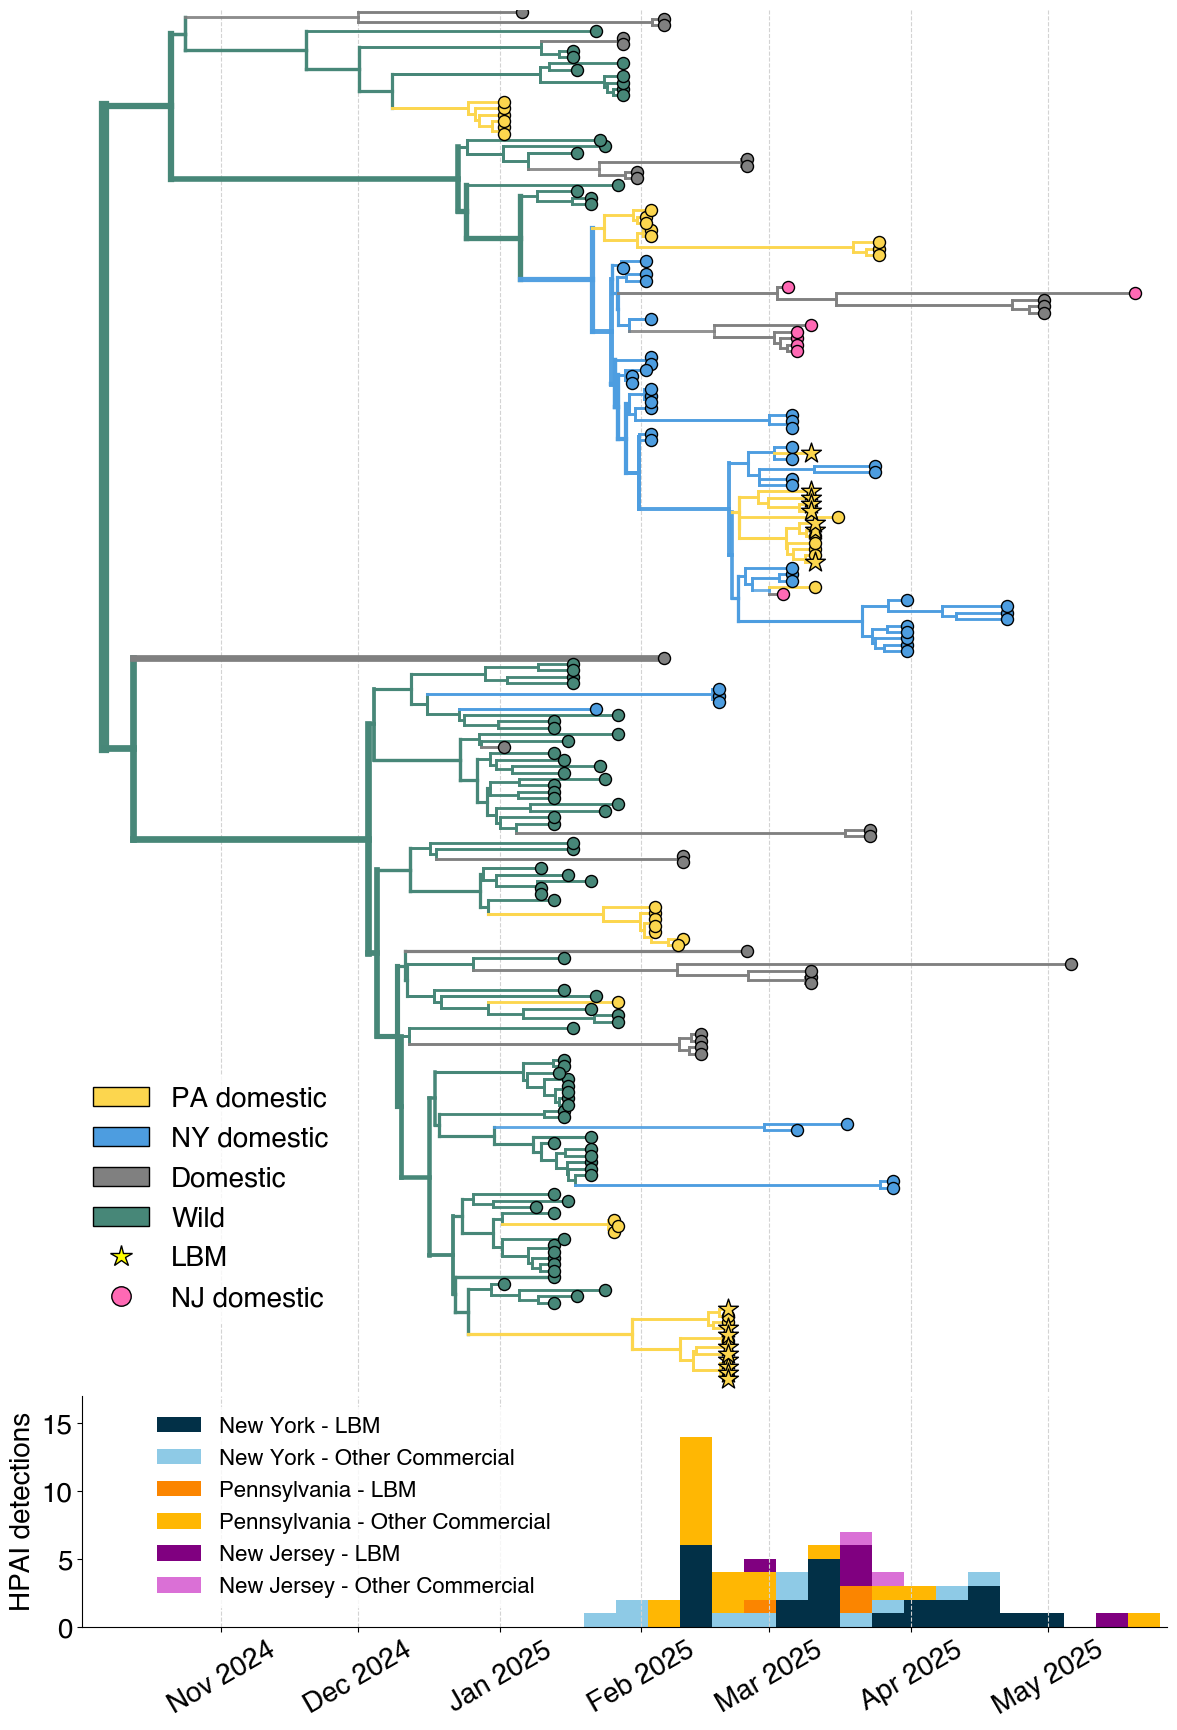

In [12]:
plot_tree_with_cases(
    metadata_dict=metadata_dict,
    com_lbm_ny_pa_nj=com_lbm_ny_pa_nj,
    lbm_tips=lbm_tips,
    combined_figure_filename='../beast_d11_dta/combined_tree_barplot.png',
    xlim=(2024.75, 2025.4),
    # xticks=(2024.75, 2025.0, 2025.25),
    tree_height=18,
    cases_height=3,
    max_cases=17, ##change to 25 for stacked bars
)

NameError: name 'weekly_pivot' is not defined

In [26]:
node_probs_df.tail(5)

,tree,node,probability
209,4-29-215seq-dta-d11.mcc.tree,209,{'wild': 1.0}
210,4-29-215seq-dta-d11.mcc.tree,210,{'wild': 1.0}
211,4-29-215seq-dta-d11.mcc.tree,211,{'wild': 1.0}
212,4-29-215seq-dta-d11.mcc.tree,212,"{'NY_domestic': 0.999498997995992, 'wild': 0.0..."
213,4-29-215seq-dta-d11.mcc.tree,213,{'NY_domestic': 1.0}


In [16]:
metadata_dict

{'4-29-215seq-dta-d11.mcc.tree': {'tree': <baltic.baltic.tree at 0x16b2deb40>,
  'metadata': {<baltic.baltic.leaf at 0x16b2dc0b0>: {'state_status': 'NY',
    'pany_dom_status': 'NY_domestic'},
   <baltic.baltic.leaf at 0x16b2de4e0>: {'state_status': 'NJ',
    'pany_dom_status': 'domestic'},
   <baltic.baltic.leaf at 0x16b2de6c0>: {'state_status': 'NJ',
    'pany_dom_status': 'domestic'},
   <baltic.baltic.leaf at 0x16b2de210>: {'state_status': 'NJ',
    'pany_dom_status': 'domestic'},
   <baltic.baltic.leaf at 0x16b2de240>: {'state_status': 'NJ',
    'pany_dom_status': 'domestic'},
   <baltic.baltic.leaf at 0x16b2dc260>: {'state_status': 'NJ',
    'pany_dom_status': 'domestic'},
   <baltic.baltic.leaf at 0x16b2dcd10>: {'state_status': 'NJ',
    'pany_dom_status': 'domestic'},
   <baltic.baltic.leaf at 0x16b2dc950>: {'state_status': 'other',
    'pany_dom_status': 'domestic'},
   <baltic.baltic.leaf at 0x16b2dc680>: {'state_status': 'other',
    'pany_dom_status': 'domestic'},
   <balti